### Import Dependencies



#### What it does

- Collects the notebook's shared libraries in one place. `sklearn` supplies the model pipelines, `optuna` handles tuning, and `unicodedata` supports accent-safe team joins.



#### Inputs

- Installed packages in the active Python environment.



#### Outputs

- Imported names such as `pd`, `np`, `optuna`, `Pipeline`, `plt`, `go`, and `unicodedata`.



#### Why it matters

- Every later cell assumes these names already exist. A missing import here would surface as harder-to-trace failures downstream.


In [51]:
from __future__ import annotations

from dataclasses import dataclass
from itertools import combinations
from pathlib import Path
from typing import Dict, List, Sequence, Tuple
import hashlib
import importlib
import pickle
import subprocess
import sys

import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import unicodedata
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import textwrap
import plotly.graph_objects as go

SHAP_IMPORT_ERROR = None
try:
    import shap
except Exception as exc:
    shap = None
    SHAP_IMPORT_ERROR = exc


### Define Paths And Tournament Constants



#### What it does

- Sets the file paths, tunable model settings, and fixed tournament inputs used everywhere else. This includes the hardcoded 2026 group draw, feature names, and reproducibility knobs.



#### Inputs

- Notebook working directory plus literals like `SEED`, `SIMULATION_RUNS`, `FORM_MATCH_WINDOW`, `OPTUNA_TRIALS`, and `FIXED_GROUPS`.



#### Outputs

- Shared constants such as `RESULTS_PATH`, `MODEL_FEATURES`, `TEAM_CONFEDS`, and `FIXED_GROUPS`.



#### Why it matters

- All training and simulation code reads from this configuration. Wrong values here would change the data, model behavior, or bracket structure.


In [52]:
BASE_DIR = Path.cwd()
EXTRA_DATA_DIR = BASE_DIR.parent
RESULTS_PATH = BASE_DIR / "results.csv"
ELO_PATH = BASE_DIR / "eloratings.csv"
FIFA_RANKING_PATH = EXTRA_DATA_DIR / "fifa_ranking_2022-10-06.csv"
WORLD_CUP_MATCHES_PATH = EXTRA_DATA_DIR / "matches_1930_2022.csv"
WORLD_CUP_SUMMARY_PATH = EXTRA_DATA_DIR / "world_cup.csv"
MODEL_CACHE_PATH = BASE_DIR / "trained_world_cup_model.pkl"

SEED = 2026
SIMULATION_RUNS = 2000
FORM_MATCH_WINDOW = 5
OPTUNA_TRIALS = 40
FORCE_RETRAIN = False
GROUP_NAMES = [chr(ord("A") + i) for i in range(12)]
HOSTS = ["United States", "Mexico", "Canada"]
MODEL_FEATURES = [
    "home_elo",
    "away_elo",
    "elo_diff",
    "elo_sum",
    "neutral",
    "home_points_avg",
    "away_points_avg",
    "home_goal_diff_avg",
    "away_goal_diff_avg",
    "home_goals_for_avg",
    "away_goals_for_avg",
    "home_goals_against_avg",
    "away_goals_against_avg",
]
OUTCOME_LABELS = ["A", "D", "H"]

TEAM_CONFEDS = {
    "Mexico": "CONCACAF",
    "South Africa": "CAF",
    "South Korea": "AFC",
    "Czech Republic": "UEFA",
    "Canada": "CONCACAF",
    "Bosnia and Herzegovina": "UEFA",
    "Qatar": "AFC",
    "Switzerland": "UEFA",
    "Brazil": "CONMEBOL",
    "Morocco": "CAF",
    "Haiti": "CONCACAF",
    "Scotland": "UEFA",
    "United States": "CONCACAF",
    "Paraguay": "CONMEBOL",
    "Australia": "AFC",
    "Turkey": "UEFA",
    "Germany": "UEFA",
    "Curacao": "CONCACAF",
    "Ivory Coast": "CAF",
    "Ecuador": "CONMEBOL",
    "Netherlands": "UEFA",
    "Japan": "AFC",
    "Sweden": "UEFA",
    "Tunisia": "CAF",
    "Belgium": "UEFA",
    "Egypt": "CAF",
    "Iran": "AFC",
    "New Zealand": "OFC",
    "Spain": "UEFA",
    "Cape Verde": "CAF",
    "Saudi Arabia": "AFC",
    "Uruguay": "CONMEBOL",
    "France": "UEFA",
    "Senegal": "CAF",
    "Iraq": "AFC",
    "Norway": "UEFA",
    "Argentina": "CONMEBOL",
    "Algeria": "CAF",
    "Austria": "UEFA",
    "Jordan": "AFC",
    "Portugal": "UEFA",
    "DR Congo": "CAF",
    "Uzbekistan": "AFC",
    "Colombia": "CONMEBOL",
    "England": "UEFA",
    "Croatia": "UEFA",
    "Ghana": "CAF",
    "Panama": "CONCACAF",
}

TEAM_NAME_ALIASES = {
    "Ivory Coast": "Ivory Coast",
    "South Korea": "South Korea",
    "Saudi Arabia": "Saudi Arabia",
    "United States": "United States",
    "New Zealand": "New Zealand",
    "South Africa": "South Africa",
    "Czech Republic": "Czechia",
    "Bosnia and Herzegovina": "Bosnia and Herzegovina",
    "Curacao": "Curacao",
    "Cape Verde": "Cape Verde",
    "DR Congo": "Democratic Republic of Congo",
}

FIXED_GROUPS = {
    "A": ["Mexico", "South Africa", "South Korea", "Czech Republic"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["United States", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Curacao", "Ivory Coast", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "DR Congo", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"],
}


### Declare Match Result Type



#### What it does

- Defines the small record that carries one simulated match through standings, knockout rounds, and reporting. Using a dataclass keeps those pieces synchronized around the same fields.



#### Inputs

- The `dataclass` decorator and the field definitions in this cell.



#### Outputs

- `MatchResult` objects with `home_team`, `away_team`, `home_goals`, `away_goals`, and `winner`.



#### Why it matters

- Later simulation cells pass matches around constantly. A stable structure here prevents mismatches between scoring, advancement, and report formatting.


In [53]:
@dataclass
class MatchResult:
    home_team: str
    away_team: str
    home_goals: int
    away_goals: int
    winner: str | None


### Normalize Team Names



#### What it does

- Builds consistent join keys for team names before any datasets are merged. It strips spacing issues, removes accents, and resolves aliases so sources that spell a country differently can still meet.



#### Inputs

- Raw team-name strings, `TEAM_NAME_ALIASES`, and `unicodedata`.



#### Outputs

- Normalized strings plus lookup helpers like `canonical_team_key()` and `_resolve_team_name()`.



#### Why it matters

- FIFA, Elo, and World Cup files do not name teams the same way. If this layer is wrong, later joins silently drop affected teams.


In [54]:
def normalize_team_name(name: str) -> str:
    return str(name).replace("\xa0", " ").strip()

def canonical_team_key(name: str) -> str:
    normalized = normalize_team_name(name)
    decomposed = unicodedata.normalize("NFKD", normalized)
    return "".join(char for char in decomposed if not unicodedata.combining(char)).casefold()

def build_name_lookup(names: Sequence[str]) -> Dict[str, str]:
    return {canonical_team_key(name): name for name in names}

def _resolve_team_name(team: str, lookup: Dict[str, str]) -> str | None:
    normalized = normalize_team_name(team)
    source_name = TEAM_NAME_ALIASES.get(normalized, normalized)
    return lookup.get(canonical_team_key(source_name))



### Encode Match Outcomes



#### What it does

- Translates match results into the notebook's three-class outcome vocabulary and converts classifier outputs back into labeled probability dictionaries. It keeps training and simulation on the same `H/D/A` convention.



#### Inputs

- Outcome sequences, classifier `classes_`, and `OUTCOME_LABELS`.



#### Outputs

- Encoded label arrays from `encode_outcomes()` and labeled probability maps from `outcome_prob_dict()`.



#### Why it matters

- Model fitting, evaluation, and match sampling all rely on the same labels. If this mapping drifts, predicted probabilities no longer line up with sampled outcomes.


In [55]:
def encode_outcomes(outcomes: Sequence[str]) -> np.ndarray:
    return pd.Categorical(outcomes, categories=OUTCOME_LABELS).codes.astype(int)

def outcome_prob_dict(classes: Sequence[object], probs: Sequence[float]) -> Dict[str, float]:
    mapped: Dict[str, float] = {label: 0.0 for label in OUTCOME_LABELS}
    for cls, prob in zip(classes, probs):
        if isinstance(cls, (int, np.integer)):
            label = OUTCOME_LABELS[int(cls)]
        else:
            label = str(cls)
        mapped[label] = float(prob)
    return mapped


### Load Match And Elo Data



#### What it does

- Reads the two primary files and the three enrichment files, then normalizes dates and team-name columns so the tables can be joined safely later.



#### Inputs

- `results.csv`, `eloratings.csv`, `fifa_ranking_2022-10-06.csv`, `matches_1930_2022.csv`, and `world_cup.csv`.



#### Outputs

- Clean `results`, `elo`, `fifa_ranking`, `world_cup_matches`, and `world_cup_summary` DataFrames.



#### Why it matters

- Later joins assume parsed datetimes and standardized team names. If loading is wrong here, every downstream feature table is affected.


In [56]:
def load_data() -> Tuple[pd.DataFrame, pd.DataFrame]:
    results = pd.read_csv(RESULTS_PATH)
    elo = pd.read_csv(ELO_PATH)

    results["date"] = pd.to_datetime(results["date"], format="mixed")
    elo["date"] = pd.to_datetime(elo["date"], format="mixed")

    results["home_team"] = results["home_team"].map(normalize_team_name)
    results["away_team"] = results["away_team"].map(normalize_team_name)
    elo["team"] = elo["team"].map(normalize_team_name)

    return results, elo

def load_external_data() -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    fifa_ranking = pd.read_csv(FIFA_RANKING_PATH)
    world_cup_matches = pd.read_csv(WORLD_CUP_MATCHES_PATH)
    world_cup_summary = pd.read_csv(WORLD_CUP_SUMMARY_PATH)

    fifa_ranking["team"] = fifa_ranking["team"].map(normalize_team_name)
    world_cup_matches["home_team"] = world_cup_matches["home_team"].map(normalize_team_name)
    world_cup_matches["away_team"] = world_cup_matches["away_team"].map(normalize_team_name)
    world_cup_summary["Champion"] = world_cup_summary["Champion"].map(normalize_team_name)
    world_cup_summary["Runner-Up"] = world_cup_summary["Runner-Up"].map(normalize_team_name)

    return fifa_ranking, world_cup_matches, world_cup_summary



### Extract Latest Elo Snapshot



#### What it does

- Reduces the full Elo time series to one current row per team by sorting by date and keeping the latest entry in each group.



#### Inputs

- `elo` as the full rating-history DataFrame.



#### Outputs

- A latest-only Elo table with `team`, `elo`, and `date`.



#### Why it matters

- Simulation needs one current strength value per team. Using stale or duplicated ratings would distort every simulated match.


In [57]:
def get_latest_elo(elo: pd.DataFrame) -> pd.DataFrame:
    latest = elo.sort_values("date").groupby("team", as_index=False).tail(1).copy()
    latest = latest[["team", "rating", "date"]].rename(columns={"rating": "elo"})
    return latest.sort_values("elo", ascending=False).reset_index(drop=True)


### Build Recent Form Features



#### What it does

- Reshapes match history into a team-centric view and computes rolling five-match averages for points, goal difference, goals scored, and goals conceded. The `shift(1)` means each match only sees prior form.



#### Inputs

- `results`-style match history and `FORM_MATCH_WINDOW`.



#### Outputs

- Match-level recent-form features and a latest per-team form snapshot.



#### Why it matters

- These features give the model short-term momentum instead of only long-run ratings. Leakage here would make the model look better than it really is.


In [58]:
def build_recent_form_features(results: pd.DataFrame, window: int = FORM_MATCH_WINDOW) -> Tuple[pd.DataFrame, pd.DataFrame]:
    working = results.reset_index(drop=True).copy()
    working["match_id"] = np.arange(len(working))

    home_history = working[["match_id", "date", "home_team", "home_score", "away_score"]].rename(
        columns={
            "home_team": "team",
            "home_score": "goals_for",
            "away_score": "goals_against",
        }
    )
    home_history["side"] = "home"

    away_history = working[["match_id", "date", "away_team", "home_score", "away_score"]].rename(
        columns={
            "away_team": "team",
            "away_score": "goals_for",
            "home_score": "goals_against",
        }
    )
    away_history["side"] = "away"

    team_history = pd.concat([home_history, away_history], ignore_index=True)
    team_history["goal_diff"] = team_history["goals_for"] - team_history["goals_against"]
    team_history["points"] = np.select(
        [
            team_history["goals_for"] > team_history["goals_against"],
            team_history["goals_for"] == team_history["goals_against"],
        ],
        [3.0, 1.0],
        default=0.0,
    )
    team_history = team_history.sort_values(["team", "date", "match_id", "side"]).reset_index(drop=True)

    history_stats = ["points", "goal_diff", "goals_for", "goals_against"]
    for stat in history_stats:
        team_history[f"recent_{stat}"] = team_history.groupby("team")[stat].transform(
            lambda values: values.shift(1).rolling(window=window, min_periods=1).mean()
        )

    home_form = team_history.loc[team_history["side"] == "home", [
        "match_id",
        "recent_points",
        "recent_goal_diff",
        "recent_goals_for",
        "recent_goals_against",
    ]].rename(
        columns={
            "recent_points": "home_points_avg",
            "recent_goal_diff": "home_goal_diff_avg",
            "recent_goals_for": "home_goals_for_avg",
            "recent_goals_against": "home_goals_against_avg",
        }
    )

    away_form = team_history.loc[team_history["side"] == "away", [
        "match_id",
        "recent_points",
        "recent_goal_diff",
        "recent_goals_for",
        "recent_goals_against",
    ]].rename(
        columns={
            "recent_points": "away_points_avg",
            "recent_goal_diff": "away_goal_diff_avg",
            "recent_goals_for": "away_goals_for_avg",
            "recent_goals_against": "away_goals_against_avg",
        }
    )

    match_features = working.merge(home_form, on="match_id", how="left").merge(away_form, on="match_id", how="left")

    latest_form = team_history.sort_values(["team", "date", "match_id"]).groupby("team", as_index=False).tail(1).copy()
    latest_form = latest_form[[
        "team",
        "recent_points",
        "recent_goal_diff",
        "recent_goals_for",
        "recent_goals_against",
    ]].rename(
        columns={
            "recent_points": "points_avg",
            "recent_goal_diff": "goal_diff_avg",
            "recent_goals_for": "goals_for_avg",
            "recent_goals_against": "goals_against_avg",
        }
    )

    return match_features, latest_form


### Build FIFA Team Profile



#### What it does

- Keeps the FIFA snapshot focused on the two signals this notebook uses: ranking position and points.

- Adds a slower-moving quality view beside Elo and recent form.



#### Inputs

- `fifa_ranking` DataFrame



#### Outputs

- `fifa_profile` with columns: `team`, `fifa_rank`, and `fifa_points`



#### Why it matters

- The power-index step expects these columns later.

- If they are missing or mis-typed, the context table loses one of its quality signals.


In [59]:
def build_fifa_team_profile(fifa_ranking: pd.DataFrame) -> pd.DataFrame:
    fifa = fifa_ranking.copy()
    fifa["fifa_rank"] = pd.to_numeric(fifa["rank"], errors="coerce")
    fifa["fifa_points"] = pd.to_numeric(fifa["points"], errors="coerce")
    return fifa[["team", "fifa_rank", "fifa_points"]].sort_values("fifa_rank").reset_index(drop=True)



### Build World Cup Team Profile



#### What it does

- Aggregates historic World Cup matches into per-team pedigree features such as points per match, goal and xG difference, win rate, titles, and finals.



#### Inputs

- `world_cup_matches` and `world_cup_summary`.



#### Outputs

- `world_cup_profile` with tournament-history features for each team.



#### Why it matters

- This gives the context layer tournament-specific information that Elo and recent form do not capture on their own.


In [60]:
def build_world_cup_team_profile(world_cup_matches: pd.DataFrame, world_cup_summary: pd.DataFrame) -> pd.DataFrame:
    matches = world_cup_matches.copy()
    matches["home_score"] = pd.to_numeric(matches["home_score"], errors="coerce")
    matches["away_score"] = pd.to_numeric(matches["away_score"], errors="coerce")
    matches["home_xg"] = pd.to_numeric(matches["home_xg"], errors="coerce")
    matches["away_xg"] = pd.to_numeric(matches["away_xg"], errors="coerce")

    home_rows = matches[["home_team", "home_score", "away_score", "home_xg", "away_xg"]].rename(
        columns={
            "home_team": "team",
            "home_score": "goals_for",
            "away_score": "goals_against",
            "home_xg": "xg_for",
            "away_xg": "xg_against",
        }
    )
    away_rows = matches[["away_team", "home_score", "away_score", "home_xg", "away_xg"]].rename(
        columns={
            "away_team": "team",
            "away_score": "goals_for",
            "home_score": "goals_against",
            "away_xg": "xg_for",
            "home_xg": "xg_against",
        }
    )

    team_matches = pd.concat([home_rows, away_rows], ignore_index=True)
    team_matches["goal_diff"] = team_matches["goals_for"] - team_matches["goals_against"]
    team_matches["xg_diff"] = team_matches["xg_for"] - team_matches["xg_against"]
    team_matches["points"] = np.select(
        [
            team_matches["goals_for"] > team_matches["goals_against"],
            team_matches["goals_for"] == team_matches["goals_against"],
        ],
        [3.0, 1.0],
        default=0.0,
    )
    team_matches["win"] = (team_matches["goals_for"] > team_matches["goals_against"]).astype(float)

    profile = team_matches.groupby("team", as_index=False).agg(
        wc_matches=("points", "size"),
        wc_points_per_match=("points", "mean"),
        wc_goal_diff_per_match=("goal_diff", "mean"),
        wc_win_rate=("win", "mean"),
        wc_xg_diff_per_match=("xg_diff", "mean"),
    )

    champions = world_cup_summary.groupby("Champion").size().rename("wc_titles")
    runner_ups = world_cup_summary.groupby("Runner-Up").size().rename("wc_runner_up")
    pedigree = pd.concat([champions, runner_ups], axis=1).fillna(0.0).reset_index().rename(columns={"index": "team"})
    pedigree["wc_finals"] = pedigree["wc_titles"] + pedigree["wc_runner_up"]

    profile = profile.merge(pedigree[["team", "wc_titles", "wc_finals"]], on="team", how="left")
    for column in ["wc_titles", "wc_finals"]:
        profile[column] = profile[column].fillna(0.0)

    return profile.sort_values(["wc_titles", "wc_points_per_match"], ascending=[False, False]).reset_index(drop=True)


### Assemble Training Matches



#### What it does

- Builds the supervised match table by attaching the latest earlier Elo rating for each home and away team, then deriving Elo summary features and the `H/D/A` label.



#### Inputs

- `results`, `elo`, and `build_recent_form_features()`.



#### Outputs

- Chronological `training_df` with model features, scores, and `outcome`.



#### Why it matters

- This is the core learning table. If the as-of joins leak future ratings, every later evaluation becomes misleading.


In [61]:
def prepare_training_data(results: pd.DataFrame, elo: pd.DataFrame) -> pd.DataFrame:
    results = results.loc[
        results["date"] >= elo["date"].min(),
        ["date", "home_team", "away_team", "home_score", "away_score", "neutral", "tournament"],
    ].copy()

    results["neutral"] = results["neutral"].astype(int)
    results["home_lookup"] = results["home_team"]
    results["away_lookup"] = results["away_team"]
    results, _ = build_recent_form_features(results)

    elo_home = elo.sort_values(["date", "team"]).rename(columns={"team": "home_lookup", "rating": "home_elo"})
    elo_away = elo.sort_values(["date", "team"]).rename(columns={"team": "away_lookup", "rating": "away_elo"})

    left_home = results.sort_values(["date", "home_lookup"])
    merged = pd.merge_asof(
        left_home,
        elo_home[["date", "home_lookup", "home_elo"]].sort_values(["date", "home_lookup"]),
        on="date",
        by="home_lookup",
        direction="backward",
        allow_exact_matches=False,
    )

    left_away = merged.sort_values(["date", "away_lookup"])
    merged = pd.merge_asof(
        left_away,
        elo_away[["date", "away_lookup", "away_elo"]].sort_values(["date", "away_lookup"]),
        on="date",
        by="away_lookup",
        direction="backward",
        allow_exact_matches=False,
    )

    merged = merged.dropna(subset=["home_elo", "away_elo"]).copy()
    merged["elo_diff"] = merged["home_elo"] - merged["away_elo"]
    merged["elo_sum"] = merged["home_elo"] + merged["away_elo"]

    merged["outcome"] = np.select(
        [
            merged["home_score"] > merged["away_score"],
            merged["home_score"] == merged["away_score"],
        ],
        ["H", "D"],
        default="A",
    )

    return merged.sort_values("date").reset_index(drop=True)



### Snapshot Latest Team Form



#### What it does

- Reuses the recent-form builder and keeps only the most recent rolling row for each team. That turns historical form into the current lookup used during simulation.



#### Inputs

- `results` match history.



#### Outputs

- `latest_form`, sorted by `points_avg`.



#### Why it matters

- Simulation needs one current form record per team, not the full training history. This bridges feature engineering and tournament-time inputs.


In [62]:
def get_latest_team_form(results: pd.DataFrame) -> pd.DataFrame:
    _, latest_form = build_recent_form_features(results[["date", "home_team", "away_team", "home_score", "away_score"]].copy())
    return latest_form.sort_values("points_avg", ascending=False, na_position="last").reset_index(drop=True)



### Split Data By Time



#### What it does

- Creates a chronological holdout split, trying 2020 first, then 2018, then an 80/20 fallback if the later cutoffs are too small.



#### Inputs

- `training_df` with a `date` column.



#### Outputs

- `train_split` and `test_split`.



#### Why it matters

- The tuner and model selector both depend on a future-looking test set. A random or broken split would overstate model quality.


In [63]:
def split_training_data(train_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    train_df = train_df.sort_values("date").reset_index(drop=True)

    primary_cutoff = pd.Timestamp("2020-01-01")
    train_split = train_df.loc[train_df["date"] < primary_cutoff].copy()
    test_split = train_df.loc[train_df["date"] >= primary_cutoff].copy()
    print(f"Temporal split @ 2020-01-01 -> train={len(train_split)}, test={len(test_split)}")
    if not train_split.empty and len(test_split) >= 500:
        return train_split, test_split

    # Fall back to an earlier cutoff only when the stricter holdout is too small or empty.
    fallback_cutoff = pd.Timestamp("2018-01-01")
    train_split = train_df.loc[train_df["date"] < fallback_cutoff].copy()
    test_split = train_df.loc[train_df["date"] >= fallback_cutoff].copy()
    print(f"Temporal split @ 2018-01-01 -> train={len(train_split)}, test={len(test_split)}")
    if not train_split.empty and not test_split.empty:
        return train_split, test_split

    # This pragmatic fallback keeps the notebook runnable if both date cutoffs collapse a split.
    split_idx = int(len(train_df) * 0.8)
    train_split = train_df.iloc[:split_idx].copy()
    test_split = train_df.iloc[split_idx:].copy()
    print(f"Temporal split fallback @ 80/20 -> train={len(train_split)}, test={len(test_split)}")
    if train_split.empty or test_split.empty:
        raise ValueError("Unable to create non-empty train/test splits from the available training data.")
    return train_split, test_split


### Define Logistic Regression Pipeline



#### What it does

- Defines the linear baseline with median imputation, feature scaling, and multinomial logistic regression inside one pipeline.



#### Inputs

- `MODEL_FEATURES`, `SEED`, and optional `params`.



#### Outputs

- A fitted-ready `Pipeline` from `build_logistic_model()`.



#### Why it matters

- This gives the notebook a simple, interpretable benchmark. The tuning loop expects the same pipeline interface from every model family.


In [64]:
def build_logistic_model(params: Dict[str, float] | None = None) -> Pipeline:
    params = params or {}
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                MODEL_FEATURES,
            )
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(
                    C=float(params.get("C", 1.0)),
                    solver=str(params.get("solver", "lbfgs")),
                    max_iter=2000,
                    random_state=SEED,
                ),
            ),
        ]
    )



### Define Random Forest Pipeline



#### What it does

- Defines the random forest candidate with median imputation and many decision trees that vote on the outcome. It skips scaling because tree splits do not need normalized inputs.



#### Inputs

- `MODEL_FEATURES`, `SEED`, and optional `params`.



#### Outputs

- A fitted-ready `Pipeline` from `build_random_forest_model()`.



#### Why it matters

- This gives the search a non-linear tabular baseline that can capture feature interactions the linear model misses.


In [65]:
def build_random_forest_model(params: Dict[str, float] | None = None) -> Pipeline:
    params = params or {}
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                    ]
                ),
                MODEL_FEATURES,
            )
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=int(params.get("n_estimators", 400)),
                    max_depth=int(params["max_depth"]) if params.get("max_depth") is not None else None,
                    min_samples_leaf=int(params.get("min_samples_leaf", 2)),
                    min_samples_split=int(params.get("min_samples_split", 2)),
                    max_features=str(params.get("max_features", "sqrt")),
                    random_state=SEED,
                    n_jobs=1,
                ),
            ),
        ]
    )



### Define Gradient Boosting Pipeline



#### What it does

- Defines the gradient boosting candidate, where trees are added sequentially to correct earlier mistakes and `subsample` adds regularization.



#### Inputs

- `MODEL_FEATURES`, `SEED`, and optional `params`.



#### Outputs

- A fitted-ready `Pipeline` from `build_gradient_boosting_model()`.



#### Why it matters

- This is often a strong family for structured sports data. The selection loop compares it directly against the other pipelines.


In [66]:
def build_gradient_boosting_model(params: Dict[str, float] | None = None) -> Pipeline:
    params = params or {}
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                    ]
                ),
                MODEL_FEATURES,
            )
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                GradientBoostingClassifier(
                    learning_rate=float(params.get("learning_rate", 0.05)),
                    n_estimators=int(params.get("n_estimators", 150)),
                    max_depth=int(params.get("max_depth", 6)),
                    min_samples_leaf=int(params.get("min_samples_leaf", 20)),
                    min_samples_split=int(params.get("min_samples_split", 2)),
                    subsample=float(params.get("subsample", 1.0)),
                    random_state=SEED,
                ),
            ),
        ]
    )



### Define Tiny Neural Network Pipeline



#### What it does

- Defines the small one-hidden-layer neural network with scaling and early stopping. It stays intentionally lightweight while still testing a different model family.



#### Inputs

- `MODEL_FEATURES`, `SEED`, and optional `params`.



#### Outputs

- A fitted-ready `Pipeline` from `build_tiny_neural_network_model()`.



#### Why it matters

- This adds a neural comparison point without turning the notebook into a heavy deep-learning workflow.


In [67]:
def build_tiny_neural_network_model(params: Dict[str, float] | None = None) -> Pipeline:
    params = params or {}
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                MODEL_FEATURES,
            )
        ]
    )

    hidden_units = int(params.get("hidden_units", 16))
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                MLPClassifier(
                    hidden_layer_sizes=(hidden_units,),
                    activation=str(params.get("activation", "relu")),
                    alpha=float(params.get("alpha", 0.0005)),
                    learning_rate_init=float(params.get("learning_rate_init", 0.001)),
                    max_iter=600,
                    early_stopping=True,
                    random_state=SEED,
                ),
            ),
        ]
    )


### Evaluate Holdout Predictions



#### What it does

- Scores a fitted model on the holdout split with accuracy and log loss. Log loss matters most here because the simulator needs well-behaved probabilities, not just correct top labels.



#### Inputs

- Fitted `model`, `test_df`, and `MODEL_FEATURES`.



#### Outputs

- A metrics dictionary with `accuracy` and `log_loss`.



#### Why it matters

- Optuna and final model selection both read these numbers. If evaluation is wrong, the notebook can choose the wrong classifier.


In [68]:
def evaluate_model(model: Pipeline, test_df: pd.DataFrame) -> Dict[str, float]:
    X_test = test_df[MODEL_FEATURES]
    y_test = test_df["outcome"]
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)
    classes = model.named_steps["classifier"].classes_
    y_test_encoded = encode_outcomes(y_test)
    if not isinstance(preds[0], str):
        preds = np.asarray(preds, dtype=int)
        accuracy = float((preds == y_test_encoded).mean())
    else:
        accuracy = float((preds == y_test).mean())

    if isinstance(classes[0], (int, np.integer)):
        y_index = y_test_encoded
    else:
        y_index = pd.Categorical(y_test, categories=classes).codes
    chosen = probs[np.arange(len(probs)), y_index]
    log_loss = float(-np.mean(np.log(np.clip(chosen, 1e-12, 1.0))))

    return {"accuracy": accuracy, "log_loss": log_loss}


### Define Optuna Search Spaces



#### What it does

- Defines the parameter ranges and sampling strategies Optuna can explore for each model family. Each branch matches the practical tuning knobs for that estimator.



#### Inputs

- `trial` and `model_name`.



#### Outputs

- A parameter dictionary tailored to one candidate model.



#### Why it matters

- The tuner can only search what this cell exposes. Poor ranges would cap model quality before fitting even starts.


In [69]:
def suggest_model_params(trial: optuna.trial.Trial, model_name: str) -> Dict[str, float | str | None]:
    if model_name == "logistic_regression":
        return {
            "C": trial.suggest_float("C", 0.01, 20.0, log=True),
            "solver": trial.suggest_categorical("solver", ["lbfgs", "newton-cg"]),
        }

    if model_name == "gradient_boosting":
        return {
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
            "n_estimators": trial.suggest_int("n_estimators", 100, 250, step=50),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 30, step=5),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        }

    if model_name == "tiny_neural_network":
        return {
            "hidden_units": trial.suggest_int("hidden_units", 8, 24, step=8),
            "activation": trial.suggest_categorical("activation", ["relu", "tanh"]),
            "alpha": trial.suggest_float("alpha", 1e-5, 1e-2, log=True),
            "learning_rate_init": trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True),
        }

    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300, step=100),
        "max_depth": trial.suggest_int("max_depth", 5, 12),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 8),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
    }



### Tune Models And Pick The Best One



#### What it does

- Runs Optuna trials, refits each family with its best parameters, and compares the tuned candidates on the holdout split.



#### Inputs

- `train_df` or `train_split`/`test_split`, model builders, `OPTUNA_TRIALS`, and `SEED`.



#### Outputs

- Best params per model plus `best_model`, `best_metrics`, and `comparison`.



#### Why it matters

- This is the model-selection heart of the notebook. Everything after this assumes one final classifier has been chosen responsibly.


In [70]:
def tune_model_with_optuna(
    model_name: str,
    train_split: pd.DataFrame,
    test_split: pd.DataFrame,
    n_trials: int = OPTUNA_TRIALS,
) -> Tuple[Dict[str, float | str | None], Dict[str, float]]:
    X_train = train_split[MODEL_FEATURES]
    y_train = train_split["outcome"]
    y_train_encoded = encode_outcomes(y_train)

    def objective(trial: optuna.trial.Trial) -> float:
        params = suggest_model_params(trial, model_name)
        if model_name == "logistic_regression":
            builder = build_logistic_model
        elif model_name == "random_forest":
            builder = build_random_forest_model
        elif model_name == "tiny_neural_network":
            builder = build_tiny_neural_network_model
        else:
            builder = build_gradient_boosting_model
        model = builder(params)
        fit_target = y_train_encoded if model_name == "tiny_neural_network" else y_train
        model.fit(X_train, fit_target)
        metrics = evaluate_model(model, test_split)
        trial.set_user_attr("accuracy", metrics["accuracy"])
        trial.set_user_attr("log_loss", metrics["log_loss"])
        # Optimize pure log loss so tuning and final model selection rank candidates the same way.
        return metrics["log_loss"]

    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = suggest_model_params(study.best_trial, model_name)
    if model_name == "logistic_regression":
        builder = build_logistic_model
    elif model_name == "random_forest":
        builder = build_random_forest_model
    elif model_name == "tiny_neural_network":
        builder = build_tiny_neural_network_model
    else:
        builder = build_gradient_boosting_model
    tuned_model = builder(best_params)
    fit_target = y_train_encoded if model_name == "tiny_neural_network" else y_train
    tuned_model.fit(X_train, fit_target)
    tuned_metrics = evaluate_model(tuned_model, test_split)
    return best_params, tuned_metrics

def train_best_model(train_df: pd.DataFrame) -> Tuple[Pipeline, Dict[str, float], pd.DataFrame]:
    train_split, test_split = split_training_data(train_df)
    X_train = train_split[MODEL_FEATURES]
    y_train = train_split["outcome"]
    y_train_encoded = encode_outcomes(y_train)

    candidate_rows: List[Dict[str, object]] = []
    best_model: Pipeline | None = None
    best_metrics: Dict[str, float] | None = None
    best_name = ""

    for model_name, builder in {
        "logistic_regression": build_logistic_model,
        "random_forest": build_random_forest_model,
        "gradient_boosting": build_gradient_boosting_model,
        "tiny_neural_network": build_tiny_neural_network_model,
    }.items():
        best_params, tuned_metrics = tune_model_with_optuna(model_name, train_split, test_split)
        model = builder(best_params)
        fit_target = y_train_encoded if model_name == "tiny_neural_network" else y_train
        model.fit(X_train, fit_target)

        candidate_rows.append(
            {
                "model": model_name,
                "accuracy": tuned_metrics["accuracy"],
                "log_loss": tuned_metrics["log_loss"],
                "optuna_trials": OPTUNA_TRIALS,
                "best_params": str(best_params),
            }
        )

        if best_metrics is None or tuned_metrics["log_loss"] < best_metrics["log_loss"] or (
            tuned_metrics["log_loss"] == best_metrics["log_loss"] and tuned_metrics["accuracy"] > best_metrics["accuracy"]
        ):
            best_model = model
            best_metrics = tuned_metrics
            best_name = model_name

    assert best_model is not None and best_metrics is not None
    best_metrics = dict(best_metrics)
    best_metrics["model_name"] = best_name

    comparison = pd.DataFrame(candidate_rows).sort_values(
        ["log_loss", "accuracy"],
        ascending=[True, False],
    ).reset_index(drop=True)
    return best_model, best_metrics, comparison



### Cache The Best Fitted Model



#### What it does

- Hashes the current training configuration and saves or reloads the chosen fitted pipeline, metrics, and comparison table from disk.



#### Inputs

- `model`, `metrics`, `comparison`, `MODEL_FEATURES`, `OPTUNA_TRIALS`, and `MODEL_CACHE_PATH`.



#### Outputs

- Cache helpers and the `trained_world_cup_model.pkl` payload.



#### Why it matters

- Training and tuning are the slowest steps. Correct cache invalidation keeps reruns fast without reusing stale model artifacts.


In [71]:
def _current_config_hash() -> str:
    payload = {
        "features": MODEL_FEATURES,
        "trials": OPTUNA_TRIALS,
        "sklearn_version": sklearn.__version__,
        "numpy_version": np.__version__,
    }
    return hashlib.md5(str(payload).encode()).hexdigest()

def save_model_cache(
    model: Pipeline,
    metrics: Dict[str, float],
    comparison: pd.DataFrame,
    cache_path: Path = MODEL_CACHE_PATH,
) -> None:
    payload = {
        "model": model,
        "metrics": metrics,
        "comparison": comparison,
        "feature_columns": MODEL_FEATURES,
        "optuna_trials": OPTUNA_TRIALS,
        "config_hash": _current_config_hash(),
    }
    with cache_path.open("wb") as f:
        pickle.dump(payload, f)

def load_model_cache(cache_path: Path = MODEL_CACHE_PATH) -> Tuple[Pipeline, Dict[str, float], pd.DataFrame]:
    with cache_path.open("rb") as f:
        payload = pickle.load(f)

    stored_hash = payload.get("config_hash")
    # Missing or changed config means the cached model should be retrained instead of reused.
    if stored_hash != _current_config_hash():
        raise ValueError("Model cache is stale for the current configuration.")

    model = payload["model"]
    metrics = dict(payload["metrics"])
    comparison = payload["comparison"]
    metrics["cache_status"] = "loaded_from_cache"
    return model, metrics, comparison

def get_or_train_best_model(
    train_df: pd.DataFrame,
    force_retrain: bool = FORCE_RETRAIN,
    cache_path: Path = MODEL_CACHE_PATH,
) -> Tuple[Pipeline, Dict[str, float], pd.DataFrame]:
    if cache_path.exists() and not force_retrain:
        try:
            return load_model_cache(cache_path)
        except ValueError:
            # Re-train automatically when an old or incompatible cache is detected.
            pass

    model, metrics, comparison = train_best_model(train_df)
    metrics = dict(metrics)
    metrics["cache_status"] = "trained_and_saved"
    save_model_cache(model, metrics, comparison, cache_path)
    return model, metrics, comparison


### Align Tournament Teams To Current Data



#### What it does

- Resolves the 2026 field against the latest Elo and form tables so every requested team has one current rating and one current form record.



#### Inputs

- `latest_elo`, `latest_form`, `TEAM_CONFEDS`, and the name-lookup helpers.



#### Outputs

- `team_ratings` and `team_form` dictionaries keyed by tournament team name.



#### Why it matters

- Simulation expects one clean lookup per team. Missing or misaligned names here would break later match construction.


In [72]:
def ensure_team_ratings(latest_elo: pd.DataFrame) -> Dict[str, float]:
    lookup = build_name_lookup(latest_elo["team"].tolist())
    ratings: Dict[str, float] = {}

    for requested_team in TEAM_CONFEDS:
        actual_name = _resolve_team_name(requested_team, lookup)
        if actual_name is None:
            raise ValueError(f"Missing Elo rating for {requested_team}")
        team_rating = float(latest_elo.loc[latest_elo["team"] == actual_name, "elo"].iloc[0])
        ratings[requested_team] = team_rating

    return ratings

def ensure_team_form(latest_form: pd.DataFrame) -> Dict[str, Dict[str, float]]:
    lookup = build_name_lookup(latest_form["team"].tolist())
    team_form: Dict[str, Dict[str, float]] = {}

    for requested_team in TEAM_CONFEDS:
        actual_name = _resolve_team_name(requested_team, lookup)
        if actual_name is None:
            team_form[requested_team] = {
                "points_avg": np.nan,
                "goal_diff_avg": np.nan,
                "goals_for_avg": np.nan,
                "goals_against_avg": np.nan,
            }
            continue

        row = latest_form.loc[latest_form["team"] == actual_name].iloc[0]
        team_form[requested_team] = {
            "points_avg": float(row["points_avg"]) if pd.notna(row["points_avg"]) else np.nan,
            "goal_diff_avg": float(row["goal_diff_avg"]) if pd.notna(row["goal_diff_avg"]) else np.nan,
            "goals_for_avg": float(row["goals_for_avg"]) if pd.notna(row["goals_for_avg"]) else np.nan,
            "goals_against_avg": float(row["goals_against_avg"]) if pd.notna(row["goals_against_avg"]) else np.nan,
        }

    return team_form


### Build Team Context And Power Index



#### What it does

- Combines Elo, recent form, FIFA signals, and World Cup pedigree into one context table and weighted `power_index`. It also creates the lookup structure used during simulation.



#### Inputs

- `team_ratings`, `team_form`, `fifa_profile`, and `world_cup_profile`.



#### Outputs

- `team_context_table` and `make_team_context_lookup()` output.



#### Why it matters

- Later probability adjustment depends on this broader strength summary. If the context table is wrong, simulated odds drift in every round.


In [73]:
def _safe_float(row: pd.Series | None, col: str, fallback: float = np.nan) -> float:
    if row is None or pd.isna(row[col]):
        return float(fallback)
    return float(row[col])

def build_team_context(
    team_ratings: Dict[str, float],
    team_form: Dict[str, Dict[str, float]],
    fifa_profile: pd.DataFrame,
    world_cup_profile: pd.DataFrame,
) -> pd.DataFrame:
    fifa_lookup = build_name_lookup(fifa_profile["team"].tolist())
    wc_lookup = build_name_lookup(world_cup_profile["team"].tolist())

    rows: List[Dict[str, float | str]] = []
    for team in TEAM_CONFEDS:
        form = team_form.get(team, {})
        fifa_name = _resolve_team_name(team, fifa_lookup)
        wc_name = _resolve_team_name(team, wc_lookup)

        fifa_row = fifa_profile.loc[fifa_profile["team"] == fifa_name].iloc[0] if fifa_name is not None else None
        wc_row = world_cup_profile.loc[world_cup_profile["team"] == wc_name].iloc[0] if wc_name is not None else None

        rows.append(
            {
                "team": team,
                "elo": team_ratings[team],
                "form_points_avg": form.get("points_avg", np.nan),
                "form_goal_diff_avg": form.get("goal_diff_avg", np.nan),
                "form_goals_for_avg": form.get("goals_for_avg", np.nan),
                "form_goals_against_avg": form.get("goals_against_avg", np.nan),
                "fifa_rank": _safe_float(fifa_row, "fifa_rank"),
                "fifa_points": _safe_float(fifa_row, "fifa_points"),
                "wc_matches": _safe_float(wc_row, "wc_matches"),
                "wc_points_per_match": _safe_float(wc_row, "wc_points_per_match"),
                "wc_goal_diff_per_match": _safe_float(wc_row, "wc_goal_diff_per_match"),
                "wc_win_rate": _safe_float(wc_row, "wc_win_rate"),
                "wc_xg_diff_per_match": _safe_float(wc_row, "wc_xg_diff_per_match"),
                "wc_titles": _safe_float(wc_row, "wc_titles", fallback=0.0),
                "wc_finals": _safe_float(wc_row, "wc_finals", fallback=0.0),
            }
        )

    context = pd.DataFrame(rows)
    numeric_columns = [column for column in context.columns if column != "team"]
    for column in numeric_columns:
        if context[column].isna().all():
            context[column] = 0.0
        else:
            context[column] = context[column].fillna(context[column].median())

    def zscore(series: pd.Series) -> pd.Series:
        std = float(series.std(ddof=0))
        if std == 0 or np.isnan(std):
            return pd.Series(np.zeros(len(series)), index=series.index)
        return (series - series.mean()) / std

    context["power_index"] = (
        0.40 * zscore(context["elo"])
        + 0.18 * zscore(context["form_points_avg"])
        + 0.10 * zscore(context["form_goal_diff_avg"])
        + 0.10 * zscore(context["fifa_points"])
        + 0.05 * zscore(-context["fifa_rank"])
        + 0.07 * zscore(context["wc_points_per_match"])
        + 0.03 * zscore(context["wc_xg_diff_per_match"])
        + 0.04 * zscore(context["wc_titles"])
        + 0.03 * zscore(context["wc_finals"])
    )

    return context.sort_values("power_index", ascending=False).reset_index(drop=True)

def make_team_context_lookup(team_context_table: pd.DataFrame) -> Dict[str, Dict[str, float]]:
    lookup: Dict[str, Dict[str, float]] = {}
    for _, row in team_context_table.iterrows():
        lookup[str(row["team"])] = {
            key: float(row[key])
            for key in team_context_table.columns
            if key != "team"
        }
    return lookup


### Build Match Feature Row



#### What it does

- Turns two team names into the exact 14-column row the trained pipeline expects at simulation time.



#### Inputs

- `home_team`, `away_team`, `team_ratings`, `team_form`, and `neutral`.



#### Outputs

- A one-row feature DataFrame from `make_feature_frame()`.



#### Why it matters

- The model can only score future matches if inputs match the training schema exactly. A bad feature row breaks every downstream prediction.


In [74]:
def make_feature_frame(
    home_team: str,
    away_team: str,
    team_ratings: Dict[str, float],
    team_form: Dict[str, Dict[str, float]],
    neutral: bool = True,
) -> pd.DataFrame:
    home_elo = team_ratings[home_team]
    away_elo = team_ratings[away_team]
    home_form = team_form.get(home_team, {})
    away_form = team_form.get(away_team, {})
    return pd.DataFrame(
        [
            {
                "home_elo": home_elo,
                "away_elo": away_elo,
                "elo_diff": home_elo - away_elo,
                "elo_sum": home_elo + away_elo,
                "neutral": int(neutral),
                "home_points_avg": home_form.get("points_avg", np.nan),
                "away_points_avg": away_form.get("points_avg", np.nan),
                "home_goal_diff_avg": home_form.get("goal_diff_avg", np.nan),
                "away_goal_diff_avg": away_form.get("goal_diff_avg", np.nan),
                "home_goals_for_avg": home_form.get("goals_for_avg", np.nan),
                "away_goals_for_avg": away_form.get("goals_for_avg", np.nan),
                "home_goals_against_avg": home_form.get("goals_against_avg", np.nan),
                "away_goals_against_avg": away_form.get("goals_against_avg", np.nan),
            }
        ]
    )


### Adjust Match Probabilities With Context



#### What it does

- Blends raw model probabilities with the power-index prior and slightly shrinks draws when the strength gap is large. The same cell also wraps that logic in `predict_outcome_probs()`.



#### Inputs

- Model `probs`, `team_context`, `model`, team names, `team_ratings`, and `team_form`.



#### Outputs

- Adjusted `H/D/A` probabilities and a prediction helper for simulation.



#### Why it matters

- This bridges match-level model output and broader team context. Later sampling assumes these probabilities are calibrated and coherent.


In [75]:
def adjust_probs_with_team_context(
    probs: Dict[str, float],
    home_team: str,
    away_team: str,
    team_context: Dict[str, Dict[str, float]],
) -> Dict[str, float]:
    home_context = team_context.get(home_team, {})
    away_context = team_context.get(away_team, {})
    power_diff = home_context.get("power_index", 0.0) - away_context.get("power_index", 0.0)

    non_draw_total = probs["H"] + probs["A"]
    if non_draw_total <= 0:
        return probs

    model_home_share = probs["H"] / non_draw_total
    prior_home_share = float(1.0 / (1.0 + np.exp(-power_diff)))
    blended_home_share = 0.80 * model_home_share + 0.20 * prior_home_share

    draw_scale = max(0.88, 1.0 - 0.04 * min(abs(power_diff), 3.0))
    adjusted_draw = probs["D"] * draw_scale
    adjusted_non_draw = max(1.0 - adjusted_draw, 0.0)

    adjusted_home = adjusted_non_draw * blended_home_share
    adjusted_away = adjusted_non_draw * (1.0 - blended_home_share)
    total = adjusted_home + adjusted_draw + adjusted_away

    return {
        "H": adjusted_home / total,
        "D": adjusted_draw / total,
        "A": adjusted_away / total,
    }

def predict_outcome_probs(
    model: Pipeline,
    home_team: str,
    away_team: str,
    team_ratings: Dict[str, float],
    team_form: Dict[str, Dict[str, float]],
    team_context: Dict[str, Dict[str, float]],
) -> Dict[str, float]:
    frame = make_feature_frame(home_team, away_team, team_ratings, team_form, neutral=True)
    probs = model.predict_proba(frame)[0]
    classes = model.named_steps["classifier"].classes_
    base_probs = outcome_prob_dict(classes, probs)
    return adjust_probs_with_team_context(base_probs, home_team, away_team, team_context)


### Estimate Goals And Sample Scores



#### What it does

- Estimates home and away expected goals from recent attacking and defensive form, then samples a Poisson scoreline that matches the chosen result.



#### Inputs

- Team names, `team_ratings`, `team_form`, sampled `outcome`, and `rng`.



#### Outputs

- `home_lambda`, `away_lambda`, and a compatible sampled scoreline.



#### Why it matters

- Group tables and reports need realistic goals, not just winners. This cell turns outcome probabilities into football scores.


In [76]:
def _expected_goals_for_match(
    home_team: str,
    away_team: str,
    team_ratings: Dict[str, float],
    team_form: Dict[str, Dict[str, float]],
) -> Tuple[float, float]:
    home_form = team_form.get(home_team, {})
    away_form = team_form.get(away_team, {})

    def blended_base(*values: float) -> float:
        valid = [float(value) for value in values if pd.notna(value)]
        return float(np.mean(valid)) if valid else 1.35

    home_base = blended_base(home_form.get("goals_for_avg", np.nan), away_form.get("goals_against_avg", np.nan))
    away_base = blended_base(away_form.get("goals_for_avg", np.nan), home_form.get("goals_against_avg", np.nan))
    elo_diff = float(team_ratings[home_team] - team_ratings[away_team])
    home_multiplier = float(np.clip(np.exp(elo_diff / 1600.0), 0.75, 1.35))
    away_multiplier = float(np.clip(np.exp(-elo_diff / 1600.0), 0.75, 1.35))

    home_lambda = float(np.clip(home_base * home_multiplier, 0.2, 3.5))
    away_lambda = float(np.clip(away_base * away_multiplier, 0.2, 3.5))
    return home_lambda, away_lambda

def sample_scoreline(
    outcome: str,
    home_lambda: float,
    away_lambda: float,
    rng: np.random.Generator,
) -> Tuple[int, int]:
    # Cap retries so Monte Carlo runtime stays predictable across large tournament batches.
    for _ in range(20):
        home_goals = int(rng.poisson(home_lambda))
        away_goals = int(rng.poisson(away_lambda))
        if outcome == "H" and home_goals > away_goals:
            return home_goals, away_goals
        if outcome == "A" and away_goals > home_goals:
            return home_goals, away_goals
        if outcome == "D" and home_goals == away_goals:
            return home_goals, away_goals

    if outcome == "H":
        return 1, 0
    if outcome == "A":
        return 0, 1
    return 1, 1


### Simulate One Match



#### What it does

- Combines probability prediction, outcome sampling, scoreline sampling, and optional penalty resolution into one reusable match simulator.



#### Inputs

- `model`, two teams, `team_ratings`, `team_form`, `team_context`, `rng`, and `knockout`.



#### Outputs

- One `MatchResult`.



#### Why it matters

- Group play, knockout rounds, and Monte Carlo all build on this function. If it is wrong, the whole tournament logic is wrong.


In [77]:
def simulate_match(
    model: Pipeline,
    home_team: str,
    away_team: str,
    team_ratings: Dict[str, float],
    team_form: Dict[str, Dict[str, float]],
    team_context: Dict[str, Dict[str, float]],
    rng: np.random.Generator,
    knockout: bool = False,
) -> MatchResult:
    probs = predict_outcome_probs(model, home_team, away_team, team_ratings, team_form, team_context)
    outcome = str(rng.choice(["H", "D", "A"], p=[probs["H"], probs["D"], probs["A"]]))
    home_lambda, away_lambda = _expected_goals_for_match(home_team, away_team, team_ratings, team_form)
    home_goals, away_goals = sample_scoreline(outcome, home_lambda, away_lambda, rng)

    winner = None
    if home_goals > away_goals:
        winner = home_team
    elif away_goals > home_goals:
        winner = away_team
    elif knockout:
        non_draw_total = probs["H"] + probs["A"]
        if non_draw_total == 0:
            winner = str(rng.choice([home_team, away_team]))
        else:
            shootout_prob = probs["H"] / non_draw_total
            winner = home_team if rng.random() < shootout_prob else away_team

    return MatchResult(home_team, away_team, home_goals, away_goals, winner)


### Create Rating Pots



#### What it does

- Orders teams by Elo, keeps the hosts in pot one, and slices the rest of the field into 12-team chunks.



#### Inputs

- `team_ratings` and `HOSTS`.



#### Outputs

- A list of seeding pots from `create_pots()`.



#### Why it matters

- Even though fixed groups are used later, this documents how a rating-based pot layout would be formed if the draw logic changed.


In [78]:
def create_pots(team_ratings: Dict[str, float]) -> List[List[str]]:
    ordered = sorted(team_ratings, key=lambda team: team_ratings[team], reverse=True)
    non_hosts = [team for team in ordered if team not in HOSTS]
    pot1 = HOSTS + non_hosts[:9]
    remaining = [team for team in non_hosts if team not in pot1]
    pots = [pot1]
    for start in range(0, len(remaining), 12):
        pots.append(remaining[start : start + 12])
    return pots


### Validate Confederation Placement



#### What it does

- Encodes the confederation cap rules used when checking whether a team can be added to a group.



#### Inputs

- `group`, `team`, and `TEAM_CONFEDS`.



#### Outputs

- `confed_limit()` and `is_valid_group_addition()`.



#### Why it matters

- These rules are the constraint layer for any non-fixed draw logic. Without them, group construction could violate tournament limits.


In [79]:
def confed_limit(confed: str) -> int:
    return 2 if confed == "UEFA" else 1

def is_valid_group_addition(group: List[str], team: str) -> bool:
    confed = TEAM_CONFEDS[team]
    if sum(1 for member in group if TEAM_CONFEDS[member] == confed) >= confed_limit(confed):
        return False
    return len(group) < 4


### Load Fixed Groups



#### What it does

- Validates that every team in `FIXED_GROUPS` has an Elo entry and then returns a clean copy of the hardcoded 2026 groups. The `rng` argument is accepted but deliberately discarded here.



#### Inputs

- `team_ratings`, `FIXED_GROUPS`, and `rng`.



#### Outputs

- A `groups` dictionary for simulation.



#### Why it matters

- The tournament simulator depends on a complete, deterministic group stage. Missing teams here would break the run before the first match.


In [80]:
def draw_groups(team_ratings: Dict[str, float], rng: np.random.Generator) -> Dict[str, List[str]]:
    del rng
    missing_teams = sorted({team for teams in FIXED_GROUPS.values() for team in teams if team not in team_ratings})
    if missing_teams:
        raise ValueError(f"Missing Elo ratings for fixed group teams: {', '.join(missing_teams)}")

    return {group_name: teams.copy() for group_name, teams in FIXED_GROUPS.items()}


### Build Group Standings



#### What it does

- Aggregates simulated group matches into points, goals, wins, and final ranking order, with Elo used as a last tiebreaker.



#### Inputs

- `group_teams`, `matches`, and `team_ratings`.



#### Outputs

- A ranked group table DataFrame.



#### Why it matters

- Advancement depends entirely on these standings. Bad totals or sort order would send the wrong teams through.


In [81]:
def build_group_table(group_teams: Sequence[str], matches: Sequence[MatchResult], team_ratings: Dict[str, float]) -> pd.DataFrame:
    rows = {
        team: {"team": team, "pts": 0, "gf": 0, "ga": 0, "gd": 0, "wins": 0, "elo": team_ratings[team]}
        for team in group_teams
    }

    for match in matches:
        rows[match.home_team]["gf"] += match.home_goals
        rows[match.home_team]["ga"] += match.away_goals
        rows[match.away_team]["gf"] += match.away_goals
        rows[match.away_team]["ga"] += match.home_goals

        if match.home_goals > match.away_goals:
            rows[match.home_team]["pts"] += 3
            rows[match.home_team]["wins"] += 1
        elif match.away_goals > match.home_goals:
            rows[match.away_team]["pts"] += 3
            rows[match.away_team]["wins"] += 1
        else:
            rows[match.home_team]["pts"] += 1
            rows[match.away_team]["pts"] += 1

    for team in rows:
        rows[team]["gd"] = rows[team]["gf"] - rows[team]["ga"]

    table = pd.DataFrame(rows.values()).sort_values(
        ["pts", "gd", "gf", "wins", "elo"],
        ascending=[False, False, False, False, False],
    )
    table["rank"] = range(1, len(table) + 1)
    return table[["rank", "team", "pts", "gd", "gf", "ga", "wins"]].reset_index(drop=True)


### Simulate The Group Stage



#### What it does

- Plays every pairwise match inside each fixed group, builds one table per group, and collects all group-stage results.



#### Inputs

- `model`, `groups`, `team_ratings`, `team_form`, `team_context`, and `rng`.



#### Outputs

- `group_tables` and `all_matches`.



#### Why it matters

- This turns the static draw into knockout inputs. Later advancement and reporting both depend on these outputs.


In [82]:
def simulate_group_stage(
    model: Pipeline,
    groups: Dict[str, List[str]],
    team_ratings: Dict[str, float],
    team_form: Dict[str, Dict[str, float]],
    team_context: Dict[str, Dict[str, float]],
    rng: np.random.Generator,
) -> Tuple[Dict[str, pd.DataFrame], List[MatchResult]]:
    group_tables: Dict[str, pd.DataFrame] = {}
    all_matches: List[MatchResult] = []

    for group_name, teams in groups.items():
        matches: List[MatchResult] = []
        for home_team, away_team in combinations(teams, 2):
            match = simulate_match(model, home_team, away_team, team_ratings, team_form, team_context, rng, knockout=False)
            matches.append(match)
            all_matches.append(match)

        table = build_group_table(teams, matches, team_ratings)
        table.insert(0, "group", group_name)
        group_tables[group_name] = table

    return group_tables, all_matches


### Select Advancing Teams



#### What it does

- Pulls out group winners and runners-up, then ranks the 12 runners-up across groups and keeps the top four as `best_runners_up`.



#### Inputs

- `group_tables`, `team_ratings`, and `GROUP_NAMES`.



#### Outputs

- `winners`, `runners_up`, and `best_runners_up`.



#### Why it matters

- Knockout seeding only works after the field is cut to 16 teams. This cell decides who survives group play in the current code.


In [83]:
def get_advancing_teams(group_tables: Dict[str, pd.DataFrame], team_ratings: Dict[str, float]) -> Tuple[List[str], List[str], List[str]]:
    winners: List[str] = []
    runners_up: List[str] = []
    runner_up_rows: List[Dict[str, object]] = []

    for group_name in GROUP_NAMES:
        table = group_tables[group_name]
        winners.append(str(table.iloc[0]["team"]))
        runner_up_team = str(table.iloc[1]["team"])
        runners_up.append(runner_up_team)
        runner_up_rows.append(
            {
                "group": group_name,
                "team": runner_up_team,
                "pts": int(table.iloc[1]["pts"]),
                "gd": int(table.iloc[1]["gd"]),
                "gf": int(table.iloc[1]["gf"]),
                "wins": int(table.iloc[1]["wins"]),
                "elo": team_ratings[runner_up_team],
            }
        )

    runner_up_df = pd.DataFrame(runner_up_rows).sort_values(
        ["pts", "gd", "gf", "wins", "elo"],
        ascending=[False, False, False, False, False],
    )
    best_runners_up = runner_up_df.head(4)["team"].tolist()
    return winners, runners_up, best_runners_up


### Seed The Knockout Bracket



#### What it does

- Ranks the qualified teams into bracket order using band, points, goal difference, goals scored, wins, and Elo. The current code seeds group winners plus `best_runners_up`.



#### Inputs

- `group_tables`, `winners`, `runners_up`, `best_runners_up`, and `team_ratings`.



#### Outputs

- An ordered `seeds` list.



#### Why it matters

- The next cell pairs teams from opposite ends of this list. If seeding is wrong, the whole bracket path changes.


In [84]:
def rank_knockout_seeds(
    group_tables: Dict[str, pd.DataFrame],
    winners: List[str],
    runners_up: List[str],
    best_runners_up: List[str],
    team_ratings: Dict[str, float],
) -> List[str]:
    qualified_teams = set(winners) | set(best_runners_up)
    rows: List[Dict[str, object]] = []

    for group_name in GROUP_NAMES:
        table = group_tables[group_name]
        for _, row in table.iterrows():
            team = str(row["team"])
            if team not in qualified_teams:
                continue
            band = 0 if team in winners else 1
            rows.append(
                {
                    "team": team,
                    "band": band,
                    "pts": int(row["pts"]),
                    "gd": int(row["gd"]),
                    "gf": int(row["gf"]),
                    "wins": int(row["wins"]),
                    "elo": team_ratings[team],
                }
            )

    seeds = pd.DataFrame(rows).sort_values(
        ["band", "pts", "gd", "gf", "wins", "elo"],
        ascending=[True, False, False, False, False, False],
    )
    return seeds["team"].tolist()


### Simulate One Knockout Round



#### What it does

- Pairs teams from the top and bottom of the seed list and simulates each match with penalties enabled.



#### Inputs

- `teams`, `model`, `team_ratings`, `team_form`, `team_context`, and `rng`.



#### Outputs

- `winners` and round `matches`.



#### Why it matters

- This is the reusable elimination-round engine. Tournament simulation calls it repeatedly until one champion remains.


In [85]:
def play_knockout_round(
    teams: Sequence[str],
    model: Pipeline,
    team_ratings: Dict[str, float],
    team_form: Dict[str, Dict[str, float]],
    team_context: Dict[str, Dict[str, float]],
    rng: np.random.Generator,
) -> Tuple[List[str], List[MatchResult]]:
    winners: List[str] = []
    matches: List[MatchResult] = []

    for index in range(len(teams) // 2):
        home_team = teams[index]
        away_team = teams[-(index + 1)]
        match = simulate_match(model, home_team, away_team, team_ratings, team_form, team_context, rng, knockout=True)
        winners.append(match.winner or home_team)
        matches.append(match)

    return winners, matches


### Simulate A Full Tournament



#### What it does

- Orchestrates one complete tournament from fixed groups through the final using a fresh random generator for the given seed.



#### Inputs

- `model`, `team_ratings`, `team_form`, `team_context`, and `seed`.



#### Outputs

- A simulation dictionary with groups, tables, knockout matches, `best_runners_up`, and `champion`.



#### Why it matters

- Monte Carlo and reporting both depend on this one complete scenario object. If its shape changes, several later cells break.


In [86]:
def simulate_tournament(
    model: Pipeline,
    team_ratings: Dict[str, float],
    team_form: Dict[str, Dict[str, float]],
    team_context: Dict[str, Dict[str, float]],
    seed: int,
) -> Dict[str, object]:
    rng = np.random.default_rng(seed)
    groups = draw_groups(team_ratings, rng)
    group_tables, group_matches = simulate_group_stage(model, groups, team_ratings, team_form, team_context, rng)
    winners, runners_up, best_runners_up = get_advancing_teams(group_tables, team_ratings)
    seeds = rank_knockout_seeds(group_tables, winners, runners_up, best_runners_up, team_ratings)

    round_of_16_teams = seeds
    quarterfinal_teams, round_of_16_matches = play_knockout_round(round_of_16_teams, model, team_ratings, team_form, team_context, rng)
    semifinal_teams, quarterfinal_matches = play_knockout_round(quarterfinal_teams, model, team_ratings, team_form, team_context, rng)
    finalists, semifinal_matches = play_knockout_round(semifinal_teams, model, team_ratings, team_form, team_context, rng)
    champion_list, final_matches = play_knockout_round(finalists, model, team_ratings, team_form, team_context, rng)

    return {
        "groups": groups,
        "group_tables": group_tables,
        "group_matches": group_matches,
        "round_of_16": round_of_16_matches,
        "quarterfinals": quarterfinal_matches,
        "semifinals": semifinal_matches,
        "final": final_matches,
        "champion": champion_list[0],
        "best_runners_up": best_runners_up,
    }


### Estimate Title Odds With Monte Carlo



#### What it does

- Repeats the full tournament across many seeds and converts champions into title counts and percentages.



#### Inputs

- `model`, `team_ratings`, `team_form`, `team_context`, and `runs`.



#### Outputs

- A DataFrame with `titles` and `title_pct`.



#### Why it matters

- This turns one tournament path into probability estimates. The title-odds table is only as good as this loop.


In [87]:
def monte_carlo_champions(
    model: Pipeline,
    team_ratings: Dict[str, float],
    team_form: Dict[str, Dict[str, float]],
    team_context: Dict[str, Dict[str, float]],
    runs: int,
) -> pd.DataFrame:
    champions: List[str] = []
    for sim_seed in range(SEED + 1, SEED + 1 + runs):
        champions.append(simulate_tournament(model, team_ratings, team_form, team_context, sim_seed)["champion"])

    counts = pd.Series(champions).value_counts().rename_axis("team").reset_index(name="titles")
    counts["title_pct"] = 100 * counts["titles"] / runs
    return counts


### Format One Match Result



#### What it does

- Converts one `MatchResult` into a readable score line and adds a note when a knockout draw was settled on penalties.



#### Inputs

- `match` as a `MatchResult`.



#### Outputs

- One formatted string.



#### Why it matters

- The report printer relies on consistent match text. This keeps knockout summaries easy to scan.


In [88]:
def format_match(match: MatchResult) -> str:
    score = f"{match.home_team} {match.home_goals}-{match.away_goals} {match.away_team}"
    if match.winner and match.home_goals == match.away_goals:
        score += f" ({match.winner} win on pens)"
    return score


### Print The Tournament Report



#### What it does

- Prints the selected model metrics, power rankings, group draw, group tables, best runners-up, knockout results, and champion for one simulation.



#### Inputs

- `simulation`, `metrics`, `latest_elo_date`, and `team_context_table`.



#### Outputs

- A structured plain-text report in the notebook output.



#### Why it matters

- This is the main human-readable summary of one run. If it mislabels sections, debugging the simulation becomes much harder.


In [89]:
def print_tournament_report(
    simulation: Dict[str, object],
    metrics: Dict[str, float],
    latest_elo_date: pd.Timestamp,
    team_context_table: pd.DataFrame,
) -> None:
    print("2026 WORLD CUP SIMULATION")
    print("=" * 60)
    print(f"Selected model: {metrics['model_name']}")
    print(f"Model holdout accuracy: {metrics['accuracy']:.3f}")
    print(f"Model holdout log loss: {metrics['log_loss']:.3f}")
    print(f"Latest Elo snapshot used for teams: {latest_elo_date.date()}")
    print()

    print("TEAM POWER RANKINGS")
    print("-" * 60)
    print(team_context_table[["team", "power_index", "elo", "fifa_points", "wc_titles", "wc_points_per_match"]].head(12).to_string(index=False))
    print()

    print("GROUP DRAW")
    print("-" * 60)
    groups: Dict[str, List[str]] = simulation["groups"]  # type: ignore[assignment]
    for group_name in GROUP_NAMES:
        print(f"Group {group_name}: {', '.join(groups[group_name])}")
    print()

    print("GROUP STAGE TABLES")
    print("-" * 60)
    group_tables: Dict[str, pd.DataFrame] = simulation["group_tables"]  # type: ignore[assignment]
    for group_name in GROUP_NAMES:
        print(f"Group {group_name}")
        print(group_tables[group_name].to_string(index=False))
        print()

    print("BEST RUNNERS-UP")
    print("-" * 60)
    print(", ".join(simulation["best_runners_up"]))  # type: ignore[arg-type]
    print()

    print("KNOCKOUT")
    print("-" * 60)
    for round_name in ["round_of_16", "quarterfinals", "semifinals", "final"]:
        pretty_name = round_name.replace("_", " ").title()
        print(pretty_name)
        for match in simulation[round_name]:  # type: ignore[index]
            print(f"  {format_match(match)}")
        print()

    print(f"CHAMPION: {simulation['champion']}")


### Wrap The Full Notebook Flow



#### What it does

- Packages data loading, model training, one tournament run, and Monte Carlo title odds into a single callable `main()` function.



#### Inputs

- CSV files plus the helper functions and constants defined earlier.



#### Outputs

- A callable `main()` that prints the comparison table, tournament report, and title table when invoked.



#### Why it matters

- This gives the notebook a one-call entry point outside the step-by-step execution cells.


In [90]:
def main() -> None:
    results, elo = load_data()
    fifa_ranking, world_cup_matches, world_cup_summary = load_external_data()

    latest_elo = get_latest_elo(elo)
    latest_form = get_latest_team_form(results)
    fifa_profile = build_fifa_team_profile(fifa_ranking)
    world_cup_profile = build_world_cup_team_profile(world_cup_matches, world_cup_summary)

    team_ratings = ensure_team_ratings(latest_elo)
    team_form = ensure_team_form(latest_form)
    team_context_table = build_team_context(team_ratings, team_form, fifa_profile, world_cup_profile)
    team_context = make_team_context_lookup(team_context_table)

    training_df = prepare_training_data(results, elo)
    model, metrics, comparison = train_best_model(training_df)

    print("MODEL COMPARISON")
    print("-" * 60)
    print(comparison.to_string(index=False))
    print()

    simulation = simulate_tournament(model, team_ratings, team_form, team_context, SEED)
    print_tournament_report(simulation, metrics, latest_elo["date"].max(), team_context_table)
    print()

    print("TITLE ODDS")
    print("-" * 60)
    title_table = monte_carlo_champions(model, team_ratings, team_form, team_context, SIMULATION_RUNS)
    print(title_table.head(15).to_string(index=False))


### Run Setup And Model Selection



#### What it does

- Executes the notebook setup pipeline: load data, build team context, prepare the training table, and load or train the cached best model.



#### Inputs

- Source CSV files, the cache file `trained_world_cup_model.pkl`, and the helper functions above.



#### Outputs

- Globals such as `results`, `elo`, `team_ratings`, `training_df`, `model`, `metrics`, and `comparison`.



#### Why it matters

- The remaining execution cells reuse these objects instead of rebuilding them. If setup fails, simulation, SHAP, and animation cannot run.


In [91]:
results, elo = load_data()
fifa_ranking, world_cup_matches, world_cup_summary = load_external_data()

latest_elo = get_latest_elo(elo)
latest_form = get_latest_team_form(results)
fifa_profile = build_fifa_team_profile(fifa_ranking)
world_cup_profile = build_world_cup_team_profile(world_cup_matches, world_cup_summary)

team_ratings = ensure_team_ratings(latest_elo)
team_form = ensure_team_form(latest_form)
team_context_table = build_team_context(team_ratings, team_form, fifa_profile, world_cup_profile)
team_context = make_team_context_lookup(team_context_table)

training_df = prepare_training_data(results, elo)
model, metrics, comparison = get_or_train_best_model(training_df)

print(f"Model cache status: {metrics['cache_status']}")
print(f"Selected model: {metrics['model_name']}")
comparison


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Ai_H\\fifa_ranking_2022-10-06.csv'

### Prepare SHAP Environment



#### What it does

- Loads the local imports and guard rails the SHAP workflow needs, then checks that setup already created the shared model and training objects.



#### Inputs

- Notebook globals such as `MODEL_FEATURES`, `model`, `training_df`, and `metrics`.



#### Outputs

- SHAP constants plus a runtime check for missing setup state.



#### Why it matters

- This isolates notebook-specific SHAP dependencies. It prevents confusing failures later in the diagnostics flow.


In [ ]:
from __future__ import annotations

import importlib
import subprocess
import sys
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

required_names = ["MODEL_FEATURES", "OUTCOME_LABELS", "SEED", "model", "training_df", "metrics"]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(
        "Run the 'Setup And Model Selection' cell first so SHAP has a trained model and prepared training data. "
        + f"Missing: {', '.join(missing_names)}"
    )

if "shap" not in globals():
    shap = None
if "SHAP_IMPORT_ERROR" not in globals():
    SHAP_IMPORT_ERROR = None

SHAP_TARGET_OUTCOME = "H"
SHAP_BACKGROUND_SAMPLES = 60
SHAP_EXPLAIN_SAMPLES = 120




### Prepare SHAP Prediction Inputs



#### What it does

- Normalizes feature input into the model's training schema and converts `predict_proba` output into labeled `H/D/A` columns.



#### Inputs

- `model`, `MODEL_FEATURES`, `OUTCOME_LABELS`, and candidate feature values.



#### Outputs

- `_coerce_feature_frame()` and `predict_outcome_probability_frame()`.



#### Why it matters

- SHAP needs a stable prediction wrapper around the fitted pipeline. Without this layer, explanation code would duplicate model-shape logic.


In [ ]:
def _coerce_feature_frame(values: pd.DataFrame | np.ndarray) -> pd.DataFrame:
    if isinstance(values, pd.DataFrame):
        return values.loc[:, MODEL_FEATURES].copy()
    return pd.DataFrame(values, columns=MODEL_FEATURES)


def predict_outcome_probability_frame(model: Pipeline, features: pd.DataFrame | np.ndarray) -> pd.DataFrame:
    frame = _coerce_feature_frame(features)
    probs = model.predict_proba(frame)
    labels: List[str] = []
    for cls in model.named_steps["classifier"].classes_:
        if isinstance(cls, (int, np.integer)):
            labels.append(OUTCOME_LABELS[int(cls)])
        else:
            labels.append(str(cls))

    prob_frame = pd.DataFrame(probs, columns=labels, index=frame.index)
    for label in OUTCOME_LABELS:
        if label not in prob_frame.columns:
            prob_frame[label] = 0.0
    return prob_frame[OUTCOME_LABELS]




### Ensure SHAP Is Available



#### What it does

- Imports `shap` if it is already present or installs it into the active notebook kernel and retries the import.



#### Inputs

- `sys.executable`, `subprocess`, and the current `shap` import state.



#### Outputs

- A ready-to-use `shap` module or a clear installation error.



#### Why it matters

- Notebook kernels often differ from the shell environment. This keeps diagnostics from failing just because the package is missing there.


In [ ]:
def ensure_shap_available() -> "object":
    global shap, SHAP_IMPORT_ERROR
    if shap is not None:
        return shap

    install_cmd = [sys.executable, "-m", "pip", "install", "--upgrade", "shap", "opencv-python>=4.13.0"]
    print("`shap` is not installed in this notebook kernel. Installing it now...")
    try:
        subprocess.check_call(install_cmd)
        importlib.invalidate_caches()
        import shap as shap_module
        shap = shap_module
        SHAP_IMPORT_ERROR = None
        return shap
    except Exception as exc:
        detail = f" Original import error: {SHAP_IMPORT_ERROR}" if SHAP_IMPORT_ERROR is not None else ""
        install_text = " ".join(install_cmd)
        raise ImportError(
            "Unable to import or install `shap` in the active notebook kernel."
            + detail
            + f" Run `{install_text}` in the same kernel environment, then rerun this cell."
        ) from exc




### Plot SHAP Summaries



#### What it does

- Samples background and explanation rows, runs a permutation SHAP explainer on the home-win probability, and draws beeswarm and bar plots.



#### Inputs

- `model`, `training_df`, `metrics`, SHAP constants, and the helper functions above.



#### Outputs

- `shap_values` plus two inline plots.



#### Why it matters

- This turns the trained classifier into something inspectable. It helps verify that the model is leaning on sensible football features.


In [ ]:
def plot_shap_summary(
    model: Pipeline,
    training_df: pd.DataFrame,
    target_label: str = SHAP_TARGET_OUTCOME,
    background_samples: int = SHAP_BACKGROUND_SAMPLES,
    explain_samples: int = SHAP_EXPLAIN_SAMPLES,
    random_state: int = SEED,
) -> "shap.Explanation":
    shap_module = ensure_shap_available()
    if target_label not in OUTCOME_LABELS:
        raise ValueError(f"target_label must be one of {OUTCOME_LABELS}.")

    feature_frame = training_df[MODEL_FEATURES].copy()
    if feature_frame.empty:
        raise ValueError("Training data is empty, so SHAP plots cannot be generated.")

    background_n = min(background_samples, len(feature_frame))
    explain_n = min(explain_samples, len(feature_frame))
    background = feature_frame.sample(n=background_n, random_state=random_state).reset_index(drop=True)
    explain_frame = feature_frame.sample(n=explain_n, random_state=random_state + 1).reset_index(drop=True)

    def predict_target(values: pd.DataFrame | np.ndarray) -> np.ndarray:
        probs = predict_outcome_probability_frame(model, values)
        return probs[target_label].to_numpy()

    masker = shap_module.maskers.Independent(background)
    explainer = shap_module.PermutationExplainer(predict_target, masker)
    shap_values = explainer(explain_frame, max_evals=max(2 * len(MODEL_FEATURES) + 1, 65))

    plt.figure(figsize=(10, 6))
    shap_module.plots.beeswarm(shap_values, max_display=10, show=False)
    plt.title(f"SHAP summary for {target_label} probability ({metrics['model_name']})")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    shap_module.plots.bar(shap_values, max_display=10, show=False)
    plt.title(f"Mean absolute SHAP impact on {target_label} probability ({metrics['model_name']})")
    plt.tight_layout()
    plt.show()

    return shap_values




### Run SHAP Diagnostics



#### What it does

- Executes the SHAP summary workflow for the current trained model and leaves the explanation object in `shap_values`.



#### Inputs

- `model`, `training_df`, and `SHAP_TARGET_OUTCOME`.



#### Outputs

- Rendered SHAP plots and `shap_values`.



#### Why it matters

- Keeping the execution step separate makes the helper cells reusable while the diagnostic run stays easy to rerun.


PermutationExplainer explainer: 121it [00:13,  8.91it/s]                         


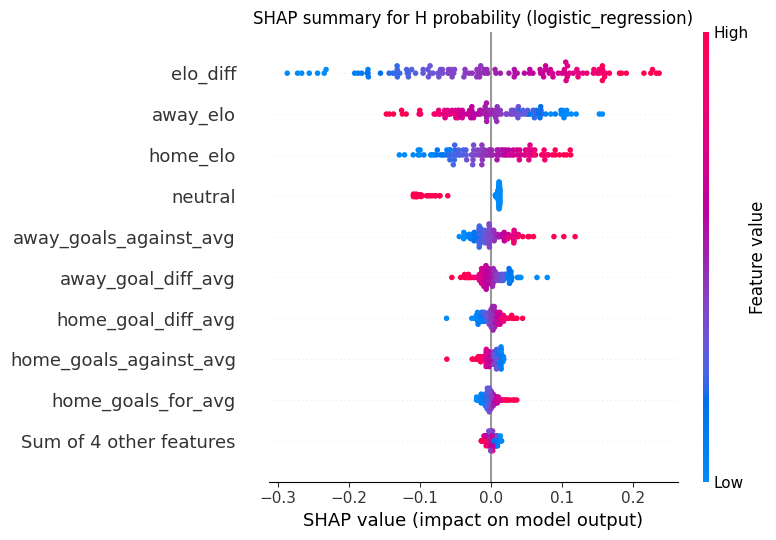

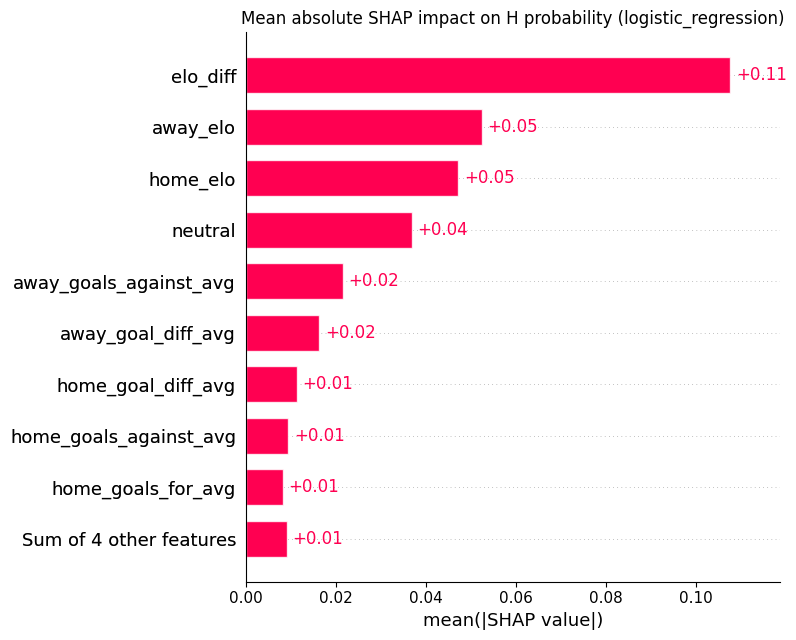

.values =
array([[ 0.10223993, -0.01730306,  0.18359897, ...,  0.00074675,
         0.0104143 , -0.01275832],
       [-0.01277724,  0.00777452, -0.00972022, ...,  0.00282524,
        -0.01463586,  0.03204638],
       [ 0.03085062,  0.02190698,  0.11033696, ...,  0.00029291,
        -0.00191136, -0.01588067],
       ...,
       [ 0.10631359, -0.14716036, -0.05129962, ..., -0.0052987 ,
         0.00394506, -0.01693039],
       [-0.03530947,  0.06883026,  0.05891566, ...,  0.00205289,
         0.00089438, -0.01590242],
       [-0.0129367 , -0.01582152, -0.06045313, ..., -0.00300831,
        -0.02655654, -0.01489489]], shape=(120, 13))

.base_values =
array([0.52810828, 0.52810828, 0.52810828, 0.52810828, 0.52810828,
       0.52810828, 0.52810828, 0.52810828, 0.52810828, 0.52810828,
       0.52810828, 0.52810828, 0.52810828, 0.52810828, 0.52810828,
       0.52810828, 0.52810828, 0.52810828, 0.52810828, 0.52810828,
       0.52810828, 0.52810828, 0.52810828, 0.52810828, 0.52810828,
       0.

In [ ]:
shap_values = plot_shap_summary(model, training_df, target_label=SHAP_TARGET_OUTCOME)
shap_values


### Simulate One Tournament Run



#### What it does

- Runs one full 2026 World Cup with the prepared model and prints the detailed report for that scenario.



#### Inputs

- `model`, `team_ratings`, `team_form`, `team_context`, `metrics`, `team_context_table`, and `SEED`.



#### Outputs

- `simulation` plus the printed tournament report.



#### Why it matters

- The bracket animation and manual inspection both depend on this concrete tournament object. No simulation means no downstream visual.


In [ ]:
simulation = simulate_tournament(model, team_ratings, team_form, team_context, SEED)
print_tournament_report(simulation, metrics, latest_elo["date"].max(), team_context_table)


2026 WORLD CUP SIMULATION
Selected model: logistic_regression
Model holdout accuracy: 0.594
Model holdout log loss: 0.876
Latest Elo snapshot used for teams: 2025-12-13

TEAM POWER RANKINGS
------------------------------------------------------------
       team  power_index    elo  fifa_points  wc_titles  wc_points_per_match
      Spain     1.666220 2171.0      1715.22        1.0             1.641791
  Argentina     1.642417 2113.0      1773.88        3.0             1.795455
     France     1.503510 2062.0      1759.78        2.0             1.794521
    England     1.349785 2042.0      1728.47        1.0             1.594595
    Germany     1.337841 1910.0      1650.21        2.0             2.107143
     Brazil     1.199229 1979.0      1841.30        5.0             2.166667
Netherlands     1.135762 1959.0      1694.51        0.0             1.890909
    Croatia     0.846638 1933.0      1645.64        0.0             1.566667
    Belgium     0.753107 1849.0      1816.71        0.0 

### Convert Results To Bracket Data



#### What it does

- Repacks knockout `MatchResult` objects into plain dictionaries that the animation code can draw without knowing simulation internals.



#### Inputs

- `simulation` as the tournament result dictionary.



#### Outputs

- `bracket_data` keyed by knockout round.



#### Why it matters

- The renderer expects a clean round-by-round shape. This translation keeps plotting code separate from simulation objects.


In [ ]:
def simulation_to_bracket_data(simulation: Dict[str, object]) -> Dict[str, List[Dict[str, object]]]:
    bracket_data: Dict[str, List[Dict[str, object]]] = {}
    for round_name in ["round_of_16", "quarterfinals", "semifinals", "final"]:
        matches = simulation.get(round_name, [])
        bracket_data[round_name] = [
            {
                "team_a": match.home_team,
                "team_b": match.away_team,
                "score_a": match.home_goals,
                "score_b": match.away_goals,
                "winner": match.winner if match.winner is not None else (match.home_team if match.home_goals >= match.away_goals else match.away_team),
            }
            for match in matches
        ]
    return bracket_data



### Render Knockout Bracket Animation



#### What it does

- Draws the five-frame knockout animation with the space palette, match cards, connectors, and champion reveal, then returns inline HTML.



#### Inputs

- `bracket_data`, `title`, `interval`, `figsize`, and `stars`.



#### Outputs

- An `HTML` animation from `render_space_bracket_video()`.



#### Why it matters

- This is the visualization layer for the knockout path. The final execution cell only needs to pass prepared data into it.


In [ ]:
def render_space_bracket_video(
    bracket_data: Dict[str, List[Dict[str, object]]],
    title: str = "World Cup Knockout Journey",
    interval: int = 1200,
    figsize: Tuple[int, int] = (16, 9),
    stars: int = 180,
) -> HTML:
    import matplotlib.pyplot as plt
    from matplotlib.animation import FuncAnimation
    from matplotlib.patches import FancyBboxPatch
    from IPython.display import HTML

    labels = {
        "round_of_16": "Round of 16",
        "quarterfinals": "Quarter-finals",
        "semifinals": "Semi-finals",
        "final": "Final",
    }

    rng = np.random.default_rng(77)
    star_x = rng.uniform(0.0, 1.0, stars)
    star_y = rng.uniform(0.0, 1.0, stars)
    star_size = rng.uniform(2, 14, stars)
    star_alpha = rng.uniform(0.08, 0.45, stars)

    left_x = {"round_of_16": 0.09, "quarterfinals": 0.28, "semifinals": 0.41}
    right_x = {"round_of_16": 0.91, "quarterfinals": 0.72, "semifinals": 0.59}
    final_x = 0.50
    final_y = 0.47
    champion_y = 0.11

    left_y = {
        "round_of_16": [0.12, 0.32, 0.62, 0.82],
        "quarterfinals": [0.22, 0.72],
        "semifinals": [0.47],
    }
    right_y = {
        "round_of_16": [0.12, 0.32, 0.62, 0.82],
        "quarterfinals": [0.22, 0.72],
        "semifinals": [0.47],
    }

    palette = {
        "bg": "#050816",
        "panel": "#0b1220",
        "card": "#0f172a",
        "card_edge": "#334155",
        "divider": "#263548",
        "text": "#e5edf7",
        "muted": "#94a3b8",
        "winner_fill": "#133a63",
        "winner_glow": "#38bdf8",
        "connector": "#3dd5f3",
        "gold": "#f5c451",
        "gold_deep": "#a16207",
        "gold_fill": "#3a2a08",
        "silver": "#cbd5e1",
    }

    all_frames = [
        {"visible_rounds": 1, "show_champion": False},
        {"visible_rounds": 2, "show_champion": False},
        {"visible_rounds": 3, "show_champion": False},
        {"visible_rounds": 4, "show_champion": False},
        {"visible_rounds": 4, "show_champion": True},
    ]

    def visible_winners(visible_round_names: List[str]) -> set[str]:
        winners: set[str] = set()
        for round_name in visible_round_names:
            for match in bracket_data.get(round_name, []):
                winners.add(str(match["winner"]))
        return winners

    def draw_match_card(ax: plt.Axes, x: float, y: float, match: Dict[str, object], width: float = 0.145, height: float = 0.102, emphasis: bool = False) -> None:
        winner = str(match["winner"])
        team_a = str(match["team_a"])
        team_b = str(match["team_b"])
        score_a = str(match["score_a"])
        score_b = str(match["score_b"])
        team_a_wins = winner == team_a
        left = x - width / 2
        bottom = y - height / 2

        glow_color = palette["gold"] if emphasis else palette["winner_glow"]
        shell = FancyBboxPatch(
            (left, bottom),
            width,
            height,
            boxstyle="round,pad=0.012,rounding_size=0.018",
            linewidth=1.2,
            edgecolor=palette["gold"] if emphasis else palette["card_edge"],
            facecolor=palette["card"],
            zorder=4,
        )
        glow = FancyBboxPatch(
            (left - 0.004, bottom - 0.004),
            width + 0.008,
            height + 0.008,
            boxstyle="round,pad=0.012,rounding_size=0.022",
            linewidth=0,
            facecolor=glow_color + "22",
            zorder=3,
        )
        ax.add_patch(glow)
        ax.add_patch(shell)
        ax.plot([left + 0.008, left + width - 0.008], [y, y], color=palette["divider"], lw=1.0, zorder=5)

        top_fill = palette["winner_fill"] if team_a_wins else palette["card"]
        bottom_fill = palette["winner_fill"] if not team_a_wins else palette["card"]
        ax.add_patch(FancyBboxPatch((left + 0.006, y + 0.003), width - 0.012, height / 2 - 0.009, boxstyle="round,pad=0.008,rounding_size=0.012", linewidth=0, facecolor=top_fill, zorder=4.2))
        ax.add_patch(FancyBboxPatch((left + 0.006, bottom + 0.006), width - 0.012, height / 2 - 0.012, boxstyle="round,pad=0.008,rounding_size=0.012", linewidth=0, facecolor=bottom_fill, zorder=4.2))

        ax.text(left + 0.014, bottom + height * 0.74, team_a, ha="left", va="center", fontsize=10.2, color=palette["text"], weight="bold" if team_a_wins else "normal", zorder=6)
        ax.text(left + width - 0.016, bottom + height * 0.74, score_a, ha="right", va="center", fontsize=10.7, color=palette["text"], weight="bold" if team_a_wins else "normal", zorder=6)
        ax.text(left + 0.014, bottom + height * 0.24, team_b, ha="left", va="center", fontsize=10.2, color=palette["text"], weight="bold" if not team_a_wins else "normal", zorder=6)
        ax.text(left + width - 0.016, bottom + height * 0.24, score_b, ha="right", va="center", fontsize=10.7, color=palette["text"], weight="bold" if not team_a_wins else "normal", zorder=6)

    def connect(ax: plt.Axes, x1: float, y1: float, x2: float, y2: float, active: bool = False) -> None:
        elbow_x = x1 + (x2 - x1) * 0.55
        color = palette["gold"] if active else palette["connector"]
        alpha = 0.95 if active else 0.45
        lw = 2.7 if active else 1.7
        ax.plot([x1, elbow_x], [y1, y1], color=color, lw=lw, alpha=alpha, zorder=2)
        ax.plot([elbow_x, elbow_x], [y1, y2], color=color, lw=lw, alpha=alpha, zorder=2)
        ax.plot([elbow_x, x2], [y2, y2], color=color, lw=lw, alpha=alpha, zorder=2)

    def draw_round_title(ax: plt.Axes, x: float, text: str) -> None:
        ax.text(x, 0.955, text, ha="center", va="center", fontsize=13, color=palette["silver"], weight="bold", zorder=7)

    fig, ax = plt.subplots(figsize=figsize)

    def update(frame_index: int) -> List[object]:
        state = all_frames[frame_index]
        visible_rounds = ["round_of_16", "quarterfinals", "semifinals", "final"][: state["visible_rounds"]]
        winners_now = visible_winners(visible_rounds)

        ax.clear()
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis("off")
        fig.patch.set_facecolor(palette["bg"])
        ax.set_facecolor(palette["bg"])

        ax.scatter(star_x, star_y, s=star_size, c="#dbeafe", alpha=star_alpha, zorder=0)
        ax.scatter(star_x * 0.94 + 0.03, star_y * 0.9 + 0.05, s=star_size * 0.25, c="#67e8f9", alpha=star_alpha * 0.28, zorder=0)
        ax.add_patch(FancyBboxPatch((0.025, 0.905), 0.95, 0.065, boxstyle="round,pad=0.008,rounding_size=0.01", linewidth=0, facecolor="#0b1220cc", zorder=1))

        ax.text(0.03, 0.975, title, ha="left", va="top", fontsize=22, color=palette["text"], weight="bold", zorder=8)
        ax.text(0.03, 0.94, "Broadcast-style knockout bracket", ha="left", va="top", fontsize=11, color=palette["muted"], zorder=8)

        if "round_of_16" in visible_rounds:
            draw_round_title(ax, left_x["round_of_16"], labels["round_of_16"])
            draw_round_title(ax, right_x["round_of_16"], labels["round_of_16"])
            for match, y in zip(bracket_data["round_of_16"][:4], left_y["round_of_16"]):
                draw_match_card(ax, left_x["round_of_16"], y, match, emphasis=str(match["winner"]) in winners_now)
            for match, y in zip(bracket_data["round_of_16"][4:], right_y["round_of_16"]):
                draw_match_card(ax, right_x["round_of_16"], y, match, emphasis=str(match["winner"]) in winners_now)

        if "quarterfinals" in visible_rounds:
            draw_round_title(ax, left_x["quarterfinals"], labels["quarterfinals"])
            draw_round_title(ax, right_x["quarterfinals"], labels["quarterfinals"])
            for match, y in zip(bracket_data["quarterfinals"][:2], left_y["quarterfinals"]):
                draw_match_card(ax, left_x["quarterfinals"], y, match, emphasis=str(match["winner"]) in winners_now)
            for match, y in zip(bracket_data["quarterfinals"][2:], right_y["quarterfinals"]):
                draw_match_card(ax, right_x["quarterfinals"], y, match, emphasis=str(match["winner"]) in winners_now)
            for i, y in enumerate(left_y["round_of_16"]):
                next_match = bracket_data["quarterfinals"][i // 2]
                connect(ax, left_x["round_of_16"] + 0.08, y, left_x["quarterfinals"] - 0.08, left_y["quarterfinals"][i // 2], active=str(next_match["winner"]) == str(bracket_data["round_of_16"][i]["winner"]))
            for i, y in enumerate(right_y["round_of_16"]):
                next_match = bracket_data["quarterfinals"][2 + i // 2]
                connect(ax, right_x["round_of_16"] - 0.08, y, right_x["quarterfinals"] + 0.08, right_y["quarterfinals"][i // 2], active=str(next_match["winner"]) == str(bracket_data["round_of_16"][4 + i]["winner"]))

        if "semifinals" in visible_rounds:
            draw_round_title(ax, left_x["semifinals"], labels["semifinals"])
            draw_round_title(ax, right_x["semifinals"], labels["semifinals"])
            draw_match_card(ax, left_x["semifinals"], left_y["semifinals"][0], bracket_data["semifinals"][0], emphasis=str(bracket_data["semifinals"][0]["winner"]) in winners_now)
            draw_match_card(ax, right_x["semifinals"], right_y["semifinals"][0], bracket_data["semifinals"][1], emphasis=str(bracket_data["semifinals"][1]["winner"]) in winners_now)
            for idx, y in enumerate(left_y["quarterfinals"]):
                connect(ax, left_x["quarterfinals"] + 0.08, y, left_x["semifinals"] - 0.08, left_y["semifinals"][0], active=str(bracket_data["quarterfinals"][idx]["winner"]) == str(bracket_data["semifinals"][0]["winner"]))
            for idx, y in enumerate(right_y["quarterfinals"]):
                connect(ax, right_x["quarterfinals"] - 0.08, y, right_x["semifinals"] + 0.08, right_y["semifinals"][0], active=str(bracket_data["quarterfinals"][2 + idx]["winner"]) == str(bracket_data["semifinals"][1]["winner"]))

        if "final" in visible_rounds:
            draw_round_title(ax, final_x, labels["final"])
            draw_match_card(ax, final_x, final_y, bracket_data["final"][0], width=0.165, height=0.112, emphasis=True)
            connect(ax, left_x["semifinals"] + 0.08, left_y["semifinals"][0], final_x - 0.09, final_y, active=str(bracket_data["semifinals"][0]["winner"]) == str(bracket_data["final"][0]["winner"]))
            connect(ax, right_x["semifinals"] - 0.08, right_y["semifinals"][0], final_x + 0.09, final_y, active=str(bracket_data["semifinals"][1]["winner"]) == str(bracket_data["final"][0]["winner"]))

        if state["show_champion"]:
            champion = str(bracket_data["final"][0]["winner"])
            ax.text(0.50, 0.205, "Champion", ha="center", va="center", fontsize=13, color=palette["gold"], weight="bold", zorder=8)
            champion_box = FancyBboxPatch(
                (0.385, champion_y - 0.042),
                0.23,
                0.104,
                boxstyle="round,pad=0.018,rounding_size=0.025",
                linewidth=2.4,
                edgecolor=palette["gold"],
                facecolor=palette["gold_fill"],
                zorder=5,
            )
            champion_glow = FancyBboxPatch(
                (0.381, champion_y - 0.046),
                0.238,
                0.112,
                boxstyle="round,pad=0.018,rounding_size=0.03",
                linewidth=0,
                facecolor="#f5c45122",
                zorder=4,
            )
            ax.add_patch(champion_glow)
            ax.add_patch(champion_box)
            ax.text(0.50, champion_y + 0.010, champion, ha="center", va="center", fontsize=19, color="#fff7d6", weight="bold", zorder=8)
            ax.text(0.50, champion_y - 0.018, "World Cup Winner", ha="center", va="center", fontsize=10.5, color="#f7d774", zorder=8)
            ax.plot([final_x, 0.50], [final_y - 0.062, champion_y + 0.05], color=palette["gold"], lw=2.9, zorder=4)

        ax.text(0.96, 0.04, f"Frame {frame_index + 1} / {len(all_frames)}", ha="right", va="bottom", fontsize=10, color=palette["muted"], zorder=8)
        return []

    animation = FuncAnimation(fig, update, frames=len(all_frames), interval=interval, repeat=False)
    plt.close(fig)
    return HTML(animation.to_jshtml())


### Display The Bracket Animation



#### What it does

- Checks that a tournament has already been simulated, converts that run into bracket data, and renders the inline knockout animation.



#### Inputs

- `simulation`, `simulation_to_bracket_data()`, and `render_space_bracket_video()`.



#### Outputs

- `space_bracket_data` and rendered animation HTML.



#### Why it matters

- This is the final presentation step. Without the guard, the notebook would try to animate an undefined tournament.


In [ ]:
if "simulation" not in globals():
    raise RuntimeError("Run the tournament simulation cell first so the bracket uses the model outcome after the group stage.")

space_bracket_data = simulation_to_bracket_data(simulation)
render_space_bracket_video(
    space_bracket_data,
    title=f"2026 World Cup Knockout Mission | Champion: {simulation['champion']}",
    interval=1300,
)
